# 02 — EDA: Medical Abstracts TC Corpus

**Objetivo:** entender o segundo dataset candidato antes de qualquer decisão de modelagem.

**Atenção — este dataset NÃO tem um target de urgência.** As classes são especialidade/categoria clínica do
resumo (neoplasia, doença digestiva, doença nervosa, doença cardiovascular, condição patológica geral). Isso é
investigado explicitamente na §3 antes de decidirmos se/como ele pode servir ao Tech Challenge.


In [ ]:
%matplotlib inline
import json
import os
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

print(f"python       {platform.python_version()}")
print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


python       3.11.15
pandas       3.0.5
numpy        1.26.4
scikit-learn 1.9.0
RANDOM_STATE = 42


## 1. Estrutura

In [ ]:
train = pd.read_parquet("../data/experiments/medical_abstracts/train.parquet")
test = pd.read_parquet("../data/experiments/medical_abstracts/test.parquet")
labels = pd.read_parquet("../data/experiments/medical_abstracts/labels.parquet")

label_map = dict(zip(labels["condition_label"], labels["condition_name"]))
print("mapeamento de classes:", label_map)

for name, part in [("train", train), ("test", test)]:
    print(f"\n{name}: shape={part.shape}, colunas={list(part.columns)}")
    print(part.dtypes)

print(f"\nmemória total (train+test): "
      f"{(train.memory_usage(deep=True).sum() + test.memory_usage(deep=True).sum()) / 1024**2:.2f} MB")

train.head(3)


mapeamento de classes: {1: 'neoplasms', 2: 'digestive system diseases', 3: 'nervous system diseases', 4: 'cardiovascular diseases', 5: 'general pathological conditions'}

train: shape=(11550, 2), colunas=['condition_label', 'medical_abstract']
condition_label     int64
medical_abstract      str
dtype: object

test: shape=(2888, 2), colunas=['condition_label', 'medical_abstract']
condition_label     int64
medical_abstract      str
dtype: object

memória total (train+test): 17.17 MB


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."


In [ ]:
df = pd.concat([
    train.assign(split="train"),
    test.assign(split="test"),
], ignore_index=True)
df["condition_name"] = df["condition_label"].map(label_map)

print("nulos por coluna:")
print(df.isna().sum())
print()
print("valores únicos:", df.nunique())
print()
print("linhas totalmente duplicadas:", df.duplicated(subset=["condition_label", "medical_abstract"]).sum())
print("abstracts duplicados (ignorando classe):", df["medical_abstract"].duplicated().sum())


nulos por coluna:
condition_label     0
medical_abstract    0
split               0
condition_name      0
dtype: int64

valores únicos: condition_label         5
medical_abstract    11227
split                   2
condition_name          5
dtype: int64

linhas totalmente duplicadas: 0
abstracts duplicados (ignorando classe): 3211


## 2. Análise do texto

In [ ]:
df["char_len"] = df["medical_abstract"].str.len()
df["word_len"] = df["medical_abstract"].str.split().str.len()

text_stats = df[["char_len", "word_len"]].describe().T
text_stats["median"] = df[["char_len", "word_len"]].median()
text_stats


,count,mean,std,min,25%,50%,75%,max,median
char_len,14438.0,1230.66512,507.347695,170.0,850.0,1210.0,1589.0,3999.0,1210.0
word_len,14438.0,179.93711,76.549766,24.0,122.0,176.0,235.0,596.0,176.0


In [ ]:
empty_texts = (df["medical_abstract"].str.strip() == "").sum()
very_short = (df["word_len"] <= 5).sum()
p01, p99 = df["word_len"].quantile([0.01, 0.99])
print(f"abstracts vazios: {empty_texts}")
print(f"abstracts muito curtos (<=5 palavras): {very_short}")
print(f"faixa p1-p99 de palavras: {p01:.0f} - {p99:.0f}")


abstracts vazios: 0
abstracts muito curtos (<=5 palavras): 0
faixa p1-p99 de palavras: 43 - 383


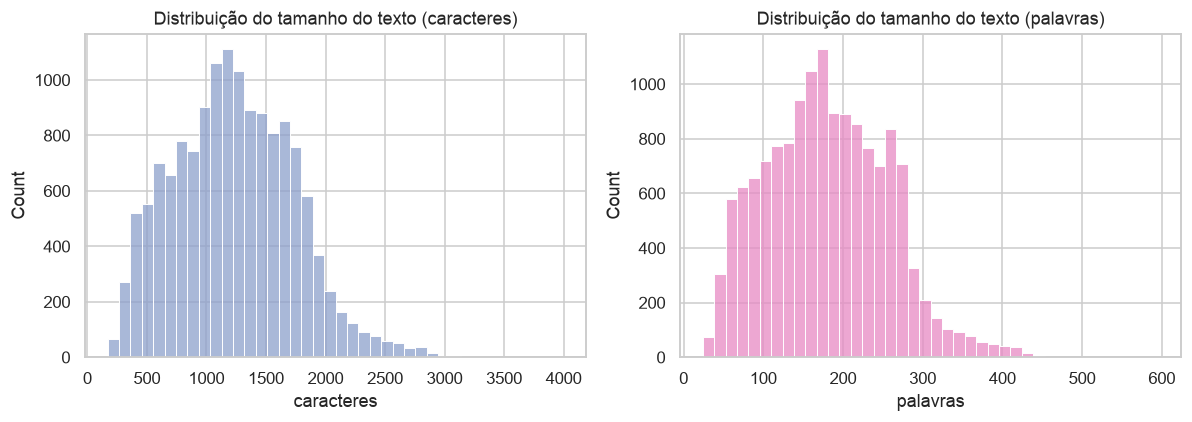

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["char_len"], bins=40, ax=axes[0], color=sns.color_palette("Set2")[2])
axes[0].set_title("Distribuição do tamanho do texto (caracteres)")
axes[0].set_xlabel("caracteres")

sns.histplot(df["word_len"], bins=40, ax=axes[1], color=sns.color_palette("Set2")[3])
axes[1].set_title("Distribuição do tamanho do texto (palavras)")
axes[1].set_xlabel("palavras")
plt.tight_layout()
plt.show()


**Leitura:** abstracts médicos reais — textos bem mais longos e variados que os laudos sintéticos (dezenas a
centenas de palavras, vocabulário técnico rico), com cauda longa à direita (alguns resumos bem mais extensos que
a mediana). Isso é o oposto do dataset 01: aqui sobra riqueza textual, falta é o target certo (próxima seção).

## 3. Análise do target — e por que ele NÃO é diretamente compatível com o Tech Challenge

In [ ]:
counts = df["condition_name"].value_counts()
props = df["condition_name"].value_counts(normalize=True)
pd.DataFrame({"contagem": counts, "proporção": props.round(4)})


,contagem,proporção
condition_name,,
general pathological conditions,4805,0.3328
neoplasms,3163,0.2191
cardiovascular diseases,3051,0.2113
nervous system diseases,1925,0.1333
digestive system diseases,1494,0.1035


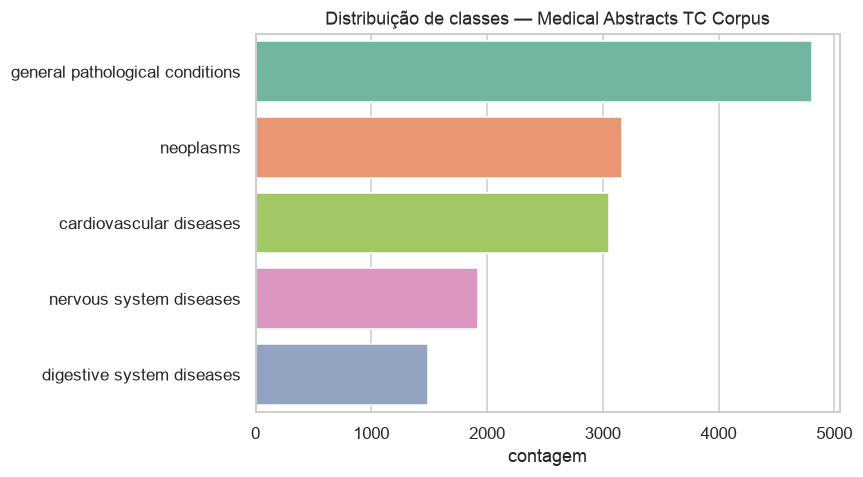

razão de desbalanceamento (classe majoritária / minoritária): 3.22x
(maior: general pathological conditions / menor: digestive system diseases)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = counts.index.tolist()
sns.countplot(data=df, y="condition_name", order=order, hue="condition_name", legend=False, palette="Set2", ax=ax)
ax.set_title("Distribuição de classes — Medical Abstracts TC Corpus")
ax.set_xlabel("contagem")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"razão de desbalanceamento (classe majoritária / minoritária): {imbalance_ratio:.2f}x")
print(f"(maior: {counts.idxmax()} / menor: {counts.idxmin()})")


### O target é especialidade clínica, não urgência

As 5 classes (`neoplasms`, `digestive system diseases`, `nervous system diseases`, `cardiovascular diseases`,
`general pathological conditions`) descrevem **de qual sistema/condição o abstract trata**, não **quão urgente**
o caso é. Um resumo de neoplasia não é, por si só, mais ou menos urgente que um de doença digestiva — a urgência
depende de gravidade clínica dentro de cada especialidade, informação que este corpus não carrega.

**Seria metodologicamente defensável mapear essas 5 classes para normal/atenção/urgente?** Não, e documentamos
por quê antes de tentar:

- Não existe nenhuma base clínica para dizer que "cardiovascular" é mais urgente que "digestivo" como categoria —
  cada especialidade tem casos leves e graves.
- Qualquer mapeamento classe→urgência seria uma decisão arbitrária nossa, não derivada dos dados, e o modelo
  aprenderia a inventar uma associação espúria entre especialidade e gravidade.
- Isso violaria a orientação de não forçar um dataset a servir a um problema que ele não descreve.

**Conclusão desta seção:** o Medical Abstracts TC Corpus é um corpus real e bem construído para classificação de
texto médico *por especialidade*, mas **não fornece o target de triagem por urgência exigido pelo Tech
Challenge**, e não deve ser forçado a fornecê-lo. Ele pode, ainda assim, ser útil como (a) benchmark de
NLP realista para comparar arquiteturas de modelo em texto médico genuíno, e (b) fonte de vocabulário/estilo para
enriquecer a geração de dados sintéticos — ver recomendação no notebook 04.

## 4. Qualidade dos dados

In [ ]:
dup_by_class = df.groupby("condition_name")["medical_abstract"].apply(lambda s: s.duplicated().sum())
unique_by_class = df.groupby("condition_name")["medical_abstract"].nunique()
total_by_class = df.groupby("condition_name").size()

quality = pd.DataFrame({
    "total": total_by_class,
    "únicos": unique_by_class,
    "duplicados": dup_by_class,
})
quality


,total,únicos,duplicados
condition_name,,,
cardiovascular diseases,3051,3051,0
digestive system diseases,1494,1494,0
general pathological conditions,4805,4805,0
neoplasms,3163,3163,0
nervous system diseases,1925,1925,0


In [ ]:
import re
weird_chars = df["medical_abstract"].apply(lambda t: bool(re.search(r"[^\x00-\x7F]", t)))
print("abstracts com caracteres fora de ASCII (possível problema de encoding):", weird_chars.sum())

if weird_chars.sum() > 0:
    print("\nexemplo:")
    ex = df[weird_chars]["medical_abstract"].iloc[0]
    print(ex[:300])


abstracts com caracteres fora de ASCII (possível problema de encoding): 0


In [ ]:
# duplicatas de texto no corpus inteiro (train+test juntos) e consistência de rótulo entre ocorrências
dup_rows_mask = df.duplicated(subset=["medical_abstract"], keep=False)
print(f"linhas envolvidas em algum texto duplicado (em qualquer lugar do corpus): "
      f"{dup_rows_mask.sum()} de {len(df)} ({dup_rows_mask.mean():.1%})")

labels_per_text = df.groupby("medical_abstract")["condition_label"].nunique()
inconsistent_texts = labels_per_text[labels_per_text > 1]
rows_inconsistent = df[df["medical_abstract"].isin(inconsistent_texts.index)]
print(f"textos duplicados com LABEL DIFERENTE entre as ocorrências: "
      f"{len(inconsistent_texts)} de {df['medical_abstract'].nunique()} textos únicos")
print(f"linhas afetadas por essa inconsistência de rótulo: {len(rows_inconsistent)}")


linhas envolvidas em algum texto duplicado (em qualquer lugar do corpus): 6140 de 14438 (42.5%)
textos duplicados com LABEL DIFERENTE entre as ocorrências: 2929 de 11227 textos únicos
linhas afetadas por essa inconsistência de rótulo: 6140


**Achado relevante:** ~43% das linhas do corpus estão envolvidas em algum texto duplicado em algum lugar do
dataset, e a maioria dessas duplicatas tem **rótulos diferentes** entre as ocorrências do mesmo texto. Isso é
consistente com a origem do corpus (derivado de coleções tipo OHSUMED, onde um mesmo abstract pode tratar de
mais de uma condição clínica e foi anotado de forma single-label por diferentes critérios) — não é um erro
nosso de leitura dos dados, é uma característica real da fonte. Investigamos o efeito disso especificamente no
split oficial train/test a seguir, porque é o ponto que mais importa para uma avaliação confiável de modelo.

## 5. Vazamento e inconsistência entre os splits train/test fornecidos pela fonte

In [ ]:
train_texts = set(train["medical_abstract"])
test_texts = set(test["medical_abstract"])
overlap = train_texts & test_texts
test_rows_affected = test["medical_abstract"].isin(overlap).sum()

print(f"abstracts únicos no train: {len(train_texts)} de {len(train)}")
print(f"abstracts únicos no test: {len(test_texts)} de {len(test)}")
print(f"abstracts (texto exato) que aparecem em AMBOS os splits: {len(overlap)}")
print(f"linhas do teste cujo texto exato também está no treino: "
      f"{test_rows_affected} de {len(test)} ({test_rows_affected/len(test):.1%})")


abstracts únicos no train: 9445 de 11550
abstracts únicos no test: 2770 de 2888
abstracts (texto exato) que aparecem em AMBOS os splits: 988
linhas do teste cujo texto exato também está no treino: 1010 de 2888 (35.0%)


In [ ]:
# para os textos em comum, o rótulo é o mesmo nos dois splits, ou diferente?
merged = train.merge(test, on="medical_abstract", suffixes=("_train", "_test"))
same_label = (merged["condition_label_train"] == merged["condition_label_test"]).sum()
diff_label = (merged["condition_label_train"] != merged["condition_label_test"]).sum()

print(f"pares (linha-treino, linha-teste) com o MESMO texto exato: {len(merged)}")
print(f"  com o MESMO rótulo nos dois: {same_label} ({same_label/len(merged):.1%})")
print(f"  com rótulo DIFERENTE entre treino e teste: {diff_label} ({diff_label/len(merged):.1%})")
print()
print("pares (label_train -> label_test) mais frequentes entre os textos divergentes:")
print(merged.loc[merged.condition_label_train != merged.condition_label_test,
                  ["condition_label_train", "condition_label_test"]].value_counts().head(5))


pares (linha-treino, linha-teste) com o MESMO texto exato: 1119
  com o MESMO rótulo nos dois: 0 (0.0%)
  com rótulo DIFERENTE entre treino e teste: 1119 (100.0%)

pares (label_train -> label_test) mais frequentes entre os textos divergentes:
condition_label_train  condition_label_test
4                      5                       154
5                      4                       139
2                      5                       108
1                      5                       103
5                      1                       101
Name: count, dtype: int64


**Isto muda a leitura da seção anterior — e é o achado mais importante desta EDA.** Não só ~35% das linhas de
teste têm o mesmo texto exato já presente no treino (vazamento clássico), como **nenhum** desses pares
compartilha o mesmo rótulo entre treino e teste: o mesmo abstract aparece com uma classe no treino e com outra
classe no teste. Ou seja, para esse subconjunto o problema não é só "o modelo já viu a resposta" — é que **a
"resposta certa" muda dependendo de qual split você olha**, porque o corpus original tem textos genuinamente
ambíguos entre classes (abstracts que tocam mais de uma especialidade) reduzidos a um único rótulo por split de
forma inconsistente.

**Implicação prática:** o benchmark oficial (avaliar no `test.parquet` como veio) não é tão "limpo" quanto a
documentação da fonte sugere à primeira vista — cerca de 1 em cada 3 exemplos de teste tem uma ambiguidade de
rótulo real e verificável contra o treino. Isso não invalida o dataset, mas qualquer número de acurácia relatado
sobre ele precisa vir acompanhado dessa ressalva, e uma comparação de modelos mais rigorosa deveria considerar
remover ou isolar esses pares ambíguos antes de comparar performances (ver notebook 03).

## 6. Síntese

In [ ]:
summary = {
    "dataset": "medical_abstracts_tc_corpus",
    "source": "https://github.com/sebischair/Medical-Abstracts-TC-Corpus (via mirror HF TimSchopf/medical_abstracts)",
    "n_rows_train": int(len(train)),
    "n_rows_test": int(len(test)),
    "n_rows_total": int(len(df)),
    "n_unique_texts": int(df["medical_abstract"].nunique()),
    "text_diversity_ratio": round(df["medical_abstract"].nunique() / len(df), 4),
    "classes": counts.index.tolist(),
    "class_counts": {k: int(v) for k, v in counts.items()},
    "imbalance_ratio": round(float(imbalance_ratio), 2),
    "has_native_urgency_target": False,
    "target_semantics": "especialidade/sistema clínico do abstract, não gravidade/urgência",
    "char_len_mean": round(float(df["char_len"].mean()), 1),
    "word_len_mean": round(float(df["word_len"].mean()), 1),
    "duplicate_rows_pct_corpus": round(float(dup_rows_mask.mean()), 4),
    "texts_with_inconsistent_label": int(len(inconsistent_texts)),
    "leakage_train_test_overlap_texts": int(len(overlap)),
    "leakage_test_rows_affected_pct": round(float(test_rows_affected / len(test)), 4),
    "leakage_overlap_same_label_pct": round(float(same_label / len(merged)), 4) if len(merged) else None,
    "random_state": RANDOM_STATE,
}

os.makedirs("../data/experiments/results", exist_ok=True)
with open("../data/experiments/results/eda_medical_abstracts_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

summary


{'dataset': 'medical_abstracts_tc_corpus',
 'source': 'https://github.com/sebischair/Medical-Abstracts-TC-Corpus (via mirror HF TimSchopf/medical_abstracts)',
 'n_rows_train': 11550,
 'n_rows_test': 2888,
 'n_rows_total': 14438,
 'n_unique_texts': 11227,
 'text_diversity_ratio': 0.7776,
 'classes': ['general pathological conditions',
  'neoplasms',
  'cardiovascular diseases',
  'nervous system diseases',
  'digestive system diseases'],
 'class_counts': {'general pathological conditions': 4805,
  'neoplasms': 3163,
  'cardiovascular diseases': 3051,
  'nervous system diseases': 1925,
  'digestive system diseases': 1494},
 'imbalance_ratio': 3.22,
 'has_native_urgency_target': False,
 'target_semantics': 'especialidade/sistema clínico do abstract, não gravidade/urgência',
 'char_len_mean': 1230.7,
 'word_len_mean': 179.9,
 'duplicate_rows_pct_corpus': 0.4253,
 'texts_with_inconsistent_label': 2929,
 'leakage_train_test_overlap_texts': 988,
 'leakage_test_rows_affected_pct': 0.3497,
 'le

### Conclusões

- **Estrutura:** 14.438 linhas (11.550 treino + 2.888 teste, split já fornecido pela fonte), sem nulos, sem
  problemas de encoding.
- **Texto:** abstracts médicos reais, muito mais longos e ricos vocabularmente que os laudos sintéticos.
- **Target:** 5 classes de especialidade clínica, desbalanceamento moderado (~3.2x) — **não é urgência**, e não
  deve ser forçado a virar urgência sem base clínica. Essa é a limitação central deste dataset para o Tech
  Challenge.
- **Qualidade/vazamento — achado mais importante:** ~35% das linhas de teste têm o texto exato também presente
  no treino, e **nesses casos o rótulo nunca coincide** entre os dois splits (0 de 1.119 pares). O corpus tem
  ambiguidade de classe real (abstracts multi-tópico reduzidos a rótulo único), herdada de sua origem tipo
  OHSUMED. Qualquer avaliação neste dataset precisa tratar esse ponto explicitamente (isolar ou remover os pares
  ambíguos), não apenas confiar no split "como veio".

Essas conclusões alimentam a comparação de datasets no notebook `04_dataset_comparison.ipynb`.